In [ ]:
import pandas as pd
from Bio import SeqIO
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
import os

fasta_dir = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/fasta_seqs/'
fp = "/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/CPDB_full_data_ark.csv"
cpdb_full = pd.read_csv(fp)

def convert_name(name):
    '''Convert name to filename used:
    ex. 1fp3A --> 1FP3_A
    '''
    if pd.isna(name) or len(name) < 5:
        return name
    # Split at position 4 (before chain identifier)
    pdb_code = name[:4].upper()
    chain = name[4:]
    fixed_name = f"{pdb_code}_{chain}"
    return fixed_name

# Apply conversion to both protein columns
cpdb_full['Protein1_filename'] = cpdb_full['Protein1'].apply(convert_name)
cpdb_full['Protein2_filename'] = cpdb_full['Protein2'].apply(convert_name)

def get_sequence_from_fasta(fasta_file, sequence_index=0):
    """
    Extract sequence from FASTA file
    
    Args:
        fasta_file: path to FASTA file
        sequence_index: which sequence to extract (0 = first)
    
    Returns:
        sequence as string
    """
    if not os.path.exists(fasta_file):
        print(f"Warning: File not found: {fasta_file}")
        return ""
    
    sequences = list(SeqIO.parse(fasta_file, "fasta"))
    if sequences:
        return str(sequences[sequence_index].seq)
    return ""

def seq_align(protein1, protein2):
    """
    Align two protein sequences and calculate percent coverage
    
    Args:
        protein1: filename for first protein
        protein2: filename for second protein
    
    Returns:
        alignment percent coverage
    """
    fasta1 = os.path.join(fasta_dir, protein1 + "_dup" + ".fasta")
    fasta2 = os.path.join(fasta_dir, protein2 + ".fasta")
    
    seq1 = get_sequence_from_fasta(fasta1)
    seq2 = get_sequence_from_fasta(fasta2)
    
    if not seq1 or not seq2:
        print(f"Warning: Empty sequence for {protein1} or {protein2}")
        return 0.0
    
    print(f"Sequence 1 ({protein1}) length: {len(seq1)}")
    print(f"Sequence 2 ({protein2}) length: {len(seq2)}")
    
    # Align
    alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    
    if not alignments:
        print(f"Warning: No alignment found for {protein1} and {protein2}")
        return 0.0
    
    alignment = alignments[0]
    # Calculate percent coverage as alignment score / length of seq2
    alignment_percent_coverage = alignment.score / len(seq2)
    
    return alignment_percent_coverage

# Apply seq_align to each row
cpdb_full['alignment_percent_coverage'] = cpdb_full.apply(
    lambda row: seq_align(row['Protein1_filename'], row['Protein2_filename']), 
    axis=1
)

In [ ]:
import numpy as np

alignment_cutoffs = {}
for i in np.arange(0.1, 1.0, 0.025):
    alignment_cutoffs[i] = len(df[df['alignment_percent_coverage'] > i])
plot_histogram(alignment_cutoffs)
               

In [ ]:
eng_cps1 = df.loc[
    df['alignment_percent_coverage'].between(0.95, 1) &
    (df['tm_score_min_difference'] > 0.01)
].copy()

In [ ]:
names_list = list(set(eng_cps1['Protein1']).union(eng_cps1['Protein2']))


In [ ]:
print(len(df))

In [ ]:
cpdb_all_names = list(set(df['Protein1']).union(df['Protein2']))


In [ ]:
len(cpdb_all_names)

In [ ]:
cpdb_all_names[:10]

In [ ]:
filtered_df = df[
    ~df['Protein1'].isin(names_list) &
    ~df['Protein2'].isin(names_list)
]
print(len(filtered_df))

In [ ]:
'1apnA' in names_list

In [ ]:
names_list

In [ ]:
filtered_df = df[(df['Protein1'] == '1cpnA') | (df['Protein2'] == '1cpnA')]
filtered_df

In [1]:
import pandas as pd
fp = "/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/CPDB_full_data_ark.csv"
df= pd.read_csv(fp)

In [70]:
df

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
0,1fp3A,1vd5A,0.67760,0.67760,0.67760,0.67760,0.939401,0.983705,a.102.1.3,a.102.1.7,0.00000,P17560,Q9RC92
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2,0.00119,P17560,Q9KB30
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2,0.00133,P17560,Q9KB30
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2,0.00124,P17560,Q9KB30
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4,0.01068,P17560,P0C0L4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4164,1xe4A,2hv2A,0.47581,0.59132,0.43224,0.53209,0.832416,0.969320,d.108.1.4,d.108.1.10,0.09985,Q9EY50,Q836T6
4165,1xe4A,2i00A,0.45702,0.58056,0.40431,0.50684,0.860363,0.974863,d.108.1.4,d.108.1.10,0.10253,Q9EY50,Q831Y9
4166,1xf8A,2hv2A,0.47354,0.59084,0.43024,0.53167,0.835343,0.965663,d.108.1.4,d.108.1.10,0.10143,Q9EY50,Q836T6
4167,1xf8A,2i00A,0.45886,0.58051,0.40551,0.50680,0.860762,0.971035,d.108.1.4,d.108.1.10,0.10129,Q9EY50,Q831Y9


In [71]:
### Update the cpdb_full_data with correct sccs (some were incorrectly assigned to ligand/small molecule (class l)

In [72]:
import pandas as pd
import re

def parse_scope_file(filepath):
    pdb_to_sccs = {}
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 6:
                continue
            
            sccs_pattern = r'^[a-z]\.\d+\.\d+\.\d+$'
            if re.match(sccs_pattern, parts[2]):
                sccs = parts[2]
                pdb_code = parts[4]
                chain_info = parts[5]
                
                if ':' in chain_info:
                    chain = chain_info.split(':')[0]
                    pdb_id = pdb_code.lower() + chain
                    
                    # If not yet assigned, or current is 'l' class and new is not
                    if pdb_id not in pdb_to_sccs:
                        pdb_to_sccs[pdb_id] = sccs
                    elif pdb_to_sccs[pdb_id].startswith('l.') and not sccs.startswith('l.'):
                        pdb_to_sccs[pdb_id] = sccs
    
    return pdb_to_sccs

pdb_to_sccs = parse_scope_file('/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/dir.des.scope.2.08-stable.txt')


In [75]:
 # Create a copy to avoid modifying original
df_sccs_fixed = df.copy()
    
    # Map proteins to sccs
df_sccs_fixed['Protein1_sccs'] = df['Protein1'].map(pdb_to_sccs)
df_sccs_fixed['Protein2_sccs'] = df['Protein2'].map(pdb_to_sccs)

In [76]:
df_sccs_fixed[df_sccs_fixed['Protein1'] == '1oq1A']

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
1416,1oq1A,1ajoA,0.39155,0.65170,0.39155,0.65170,0.871256,0.954553,b.29.1.17,b.29.1.2,0.26015,O31524,P23904
1417,1oq1A,2gdfA,0.35999,0.68750,0.34741,0.65913,0.872728,0.981008,b.29.1.17,b.29.1.1,0.31172,O31524,P08902
1418,1oq1A,1h9pA,0.37262,0.68529,0.34758,0.64038,0.908447,0.978381,b.29.1.17,b.29.1.1,0.29280,O31524,P81637
1419,1oq1A,1wuvA,0.37045,0.68478,0.34062,0.63098,0.920467,0.976041,b.29.1.17,b.29.1.1,0.29036,O31524,P14894


In [77]:
df_sccs_fixed.to_csv('CPDB_full_data_sccs_fixed.csv', index=False)


In [18]:
import pickle
with open("/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/pdb_to_uniprot/cpdb_pdb_to_uniprot.pkl", "rb") as f:
    pdb_to_uniprot = pickle.load(f)

In [21]:
df['Protein1_uniprot'] = df['Protein1'].map(pdb_to_uniprot)
df['Protein2_uniprot'] = df['Protein2'].map(pdb_to_uniprot)

In [68]:
df.to_csv("CPDB_with_uniprotID.csv", index=False)


In [22]:
df_same_uniprot = df[
    df['Protein1_uniprot'].notna() &
    (df['Protein1_uniprot'] == df['Protein2_uniprot'])
]


In [25]:
df_same_uniprot

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
871,1ajkA,1u0aA,0.56902,0.94342,0.56382,0.93477,0.986758,0.997516,b.29.1.2,b.29.1.2,0.37095,P23904,P23904
872,1ajkA,1cpmA,0.83039,0.94790,0.82277,0.93919,0.974219,0.998609,b.29.1.2,b.29.1.2,0.11642,P23904,P23904
873,1ajkA,1cpnA,0.80700,0.92456,0.80700,0.92456,0.979318,0.997953,b.29.1.2,b.29.1.2,0.11756,P23904,P23904
874,1ajkA,1byhA,0.56919,0.93909,0.56400,0.93050,0.986416,0.998572,b.29.1.2,b.29.1.2,0.36650,P23904,P23904
919,1ajoA,1cpnA,0.64425,0.96345,0.64425,0.96345,0.981037,0.997640,b.29.1.2,b.29.1.2,0.31920,P23904,P23904
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152,1fvjA,1un2A,0.50742,0.94509,0.50742,0.94509,0.984608,0.990853,c.47.1.13,c.47.1.13,0.43767,P0AEG4,P0AEG4
4154,1ti1A,1un2A,0.48785,0.93896,0.48785,0.93896,0.991267,0.995208,c.47.1.13,c.47.1.13,0.45111,P0AEG4,P0AEG4
4155,1un2A,1bq7A,0.51353,0.96431,0.51353,0.96431,0.989165,0.995577,c.47.1.13,c.47.1.13,0.45078,P0AEG4,P0AEG4
4156,1un2A,2b3sA,0.47834,0.91446,0.47593,0.90986,0.985751,0.993427,c.47.1.13,c.47.1.13,0.43393,P0AEG4,P0AEG4


In [26]:
uniprot_ids = pd.unique(
    df_same_uniprot[['Protein1_uniprot', 'Protein2_uniprot']].values.ravel()
)
uniprot_ids = [u for u in uniprot_ids if pd.notna(u)]

In [29]:
mask = (
    df['Protein1_uniprot'].isin(uniprot_ids) |
    df['Protein2_uniprot'].isin(uniprot_ids)
)

num_rows = mask.sum()
print(num_rows)

491


In [33]:
'P56217' in uniprot_ids

False

In [34]:
uniprot_ids

['P23904',
 'Q57254',
 'P22629',
 'P02701',
 'P07751',
 'Q40378',
 'P56254',
 'P00560',
 'P00807',
 'P36057',
 'P0AEG4']

In [23]:
df_same_uniprot

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
871,1ajkA,1u0aA,0.56902,0.94342,0.56382,0.93477,0.986758,0.997516,b.29.1.2,b.29.1.2,0.37095,P23904,P23904
872,1ajkA,1cpmA,0.83039,0.94790,0.82277,0.93919,0.974219,0.998609,b.29.1.2,b.29.1.2,0.11642,P23904,P23904
873,1ajkA,1cpnA,0.80700,0.92456,0.80700,0.92456,0.979318,0.997953,b.29.1.2,b.29.1.2,0.11756,P23904,P23904
874,1ajkA,1byhA,0.56919,0.93909,0.56400,0.93050,0.986416,0.998572,b.29.1.2,b.29.1.2,0.36650,P23904,P23904
919,1ajoA,1cpnA,0.64425,0.96345,0.64425,0.96345,0.981037,0.997640,b.29.1.2,b.29.1.2,0.31920,P23904,P23904
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152,1fvjA,1un2A,0.50742,0.94509,0.50742,0.94509,0.984608,0.990853,c.47.1.13,c.47.1.13,0.43767,P0AEG4,P0AEG4
4154,1ti1A,1un2A,0.48785,0.93896,0.48785,0.93896,0.991267,0.995208,c.47.1.13,c.47.1.13,0.45111,P0AEG4,P0AEG4
4155,1un2A,1bq7A,0.51353,0.96431,0.51353,0.96431,0.989165,0.995577,c.47.1.13,c.47.1.13,0.45078,P0AEG4,P0AEG4
4156,1un2A,2b3sA,0.47834,0.91446,0.47593,0.90986,0.985751,0.993427,c.47.1.13,c.47.1.13,0.43393,P0AEG4,P0AEG4


In [19]:
df.head()

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference
0,1fp3A,1vd5A,0.67760,0.67760,0.67760,0.67760,0.939401,0.983705,a.102.1.3,a.102.1.7,0.00000
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2,0.00119
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2,0.00133
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2,0.00124
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4,0.01068


In [36]:
filtered_df = df[(df['Protein1'] == '1wuvA') | (df['Protein2'] == '1wuvA')]
filtered_df.head()

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
863,1a78A,1wuvA,0.51204,0.72330,0.31958,0.45109,0.977415,0.935906,b.29.1.3,b.29.1.1,0.13151,P56217,P14894
1208,1ganA,1wuvA,0.51618,0.72738,0.32161,0.45279,0.975394,0.939503,b.29.1.3,b.29.1.1,0.13118,P56217,P14894
1315,1is3A,1wuvA,0.52203,0.73223,0.32525,0.45519,0.982348,0.921716,b.29.1.3,b.29.1.1,0.12994,Q9YIC2,P14894
1398,1n3oA,1wuvA,0.46865,0.91577,0.46865,0.91577,0.994460,0.995012,b.29.1.1,b.29.1.1,0.44712,Q8GSD2,P14894
1419,1oq1A,1wuvA,0.37045,0.68478,0.34062,0.63098,0.920467,0.976041,l.1.1.1,b.29.1.1,0.29036,O31524,P14894


In [13]:
df_035diff = df[df['tm_score_min_difference'] > 0.35]
df_035diff.to_csv('df_035tmdiff.csv')

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist((filtered_df['tm_score_min_difference']['tm_score_min_difference']), 
         bins=30, edgecolor="black", alpha=0.5)
plt.xlim(0, 1)
plt.xlabel("∆CP")
plt.ylabel("Number of Pairs")
plt.title("Distribution of ∆CPs for CPDB pairs")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist((df['tm_score_min_difference']), 
         bins=30, edgecolor="black", alpha=0.5)
plt.xlim(0, 1)
plt.xlabel("∆CP")
plt.ylabel("Number of Pairs")
plt.title("Distribution of ∆CPs for CPDB pairs")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
len(df)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the histogram of tm_score_min_difference
plt.figure(figsize=(10, 6))
plt.hist(eng_cps['tm_score_min_difference'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('TM Score Min Difference', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of TM Score Min Difference', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
eng_cps

In [ ]:
filtered = df[df['alignment_percent_coverage'].between(0.9, 1)]
count = df['Protein1'].value_counts().get('1ajkA', 0)
filtered

In [38]:
df

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
0,1fp3A,1vd5A,0.67760,0.67760,0.67760,0.67760,0.939401,0.983705,a.102.1.3,a.102.1.7,0.00000,P17560,Q9RC92
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2,0.00119,P17560,Q9KB30
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2,0.00133,P17560,Q9KB30
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2,0.00124,P17560,Q9KB30
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4,0.01068,P17560,P0C0L4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4164,1xe4A,2hv2A,0.47581,0.59132,0.43224,0.53209,0.832416,0.969320,d.108.1.4,d.108.1.10,0.09985,Q9EY50,Q836T6
4165,1xe4A,2i00A,0.45702,0.58056,0.40431,0.50684,0.860363,0.974863,d.108.1.4,d.108.1.10,0.10253,Q9EY50,Q831Y9
4166,1xf8A,2hv2A,0.47354,0.59084,0.43024,0.53167,0.835343,0.965663,d.108.1.4,d.108.1.10,0.10143,Q9EY50,Q836T6
4167,1xf8A,2i00A,0.45886,0.58051,0.40551,0.50680,0.860762,0.971035,d.108.1.4,d.108.1.10,0.10129,Q9EY50,Q831Y9


In [64]:
count = next(v for k, v in sorted_sccs if k == 'c.47.1.13')


TypeError: argument of type 'float' is not iterable

In [55]:
df[
    (df['Protein1'] == '1un2A') |
    (df['Protein2'] == '1un2A')
]


,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
4148,1a23A,1un2A,0.45417,0.81368,0.45417,0.81368,0.984426,0.988718,c.47.1.13,c.47.1.13,0.35951,P0AEG4,P0AEG4
4149,1ac1A,1un2A,0.50342,0.93870,0.50342,0.93870,0.984774,0.991518,c.47.1.13,c.47.1.13,0.43528,P0AEG4,P0AEG4
4150,1acvA,1un2A,0.50519,0.94177,0.50519,0.94177,0.983860,0.991701,c.47.1.13,c.47.1.13,0.43658,P0AEG4,P0AEG4
4151,1bedA,1un2A,0.48111,0.88504,0.46898,0.86295,0.979549,0.990983,c.47.1.13,c.47.1.13,0.39397,P32557,P0AEG4
4152,1fvjA,1un2A,0.50742,0.94509,0.50742,0.94509,0.984608,0.990853,c.47.1.13,c.47.1.13,0.43767,P0AEG4,P0AEG4
4153,1r4wA,1un2A,0.30433,0.56110,0.30433,0.56110,0.978588,0.976646,c.47.1.13,c.47.1.13,0.25677,P24473,P0AEG4
4154,1ti1A,1un2A,0.48785,0.93896,0.48785,0.93896,0.991267,0.995208,c.47.1.13,c.47.1.13,0.45111,P0AEG4,P0AEG4
4155,1un2A,1bq7A,0.51353,0.96431,0.51353,0.96431,0.989165,0.995577,c.47.1.13,c.47.1.13,0.45078,P0AEG4,P0AEG4
4156,1un2A,2b3sA,0.47834,0.91446,0.47593,0.90986,0.985751,0.993427,c.47.1.13,c.47.1.13,0.43393,P0AEG4,P0AEG4
4159,1yzxA,1un2A,0.30365,0.56550,0.30365,0.56550,0.976762,0.971317,c.47.1.13,c.47.1.13,0.26185,Q9Y2Q3,P0AEG4


In [40]:
df[
    (df['Protein1_sccs'] == 'b.29.1.1') &
    (df['Protein2_sccs'] == 'b.29.1.1')
]


,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
952,1apnA,1q8oA,0.47129,0.91694,0.44276,0.86146,0.955296,0.993365,b.29.1.1,b.29.1.1,0.41870,P02866,Q8GSD2
953,1apnA,1n3oA,0.47240,0.91876,0.44033,0.85630,0.955405,0.991634,b.29.1.1,b.29.1.1,0.41597,P02866,Q8GSD2
954,1apnA,1ciwA,0.46433,0.90249,0.44907,0.87315,0.949354,0.997121,b.29.1.1,b.29.1.1,0.42408,P02866,P02872
955,1apnA,2bqpA,0.46577,0.90637,0.45788,0.89113,0.944272,0.997203,b.29.1.1,b.29.1.1,0.43325,P02866,P02867
956,1apnA,1n47A,0.46688,0.91799,0.44941,0.88371,0.949167,0.997793,b.29.1.1,b.29.1.1,0.43430,P02866,P56625
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,2gdfA,1ioaA,0.44998,0.88733,0.44619,0.87988,0.966079,0.992010,b.29.1.1,b.29.1.1,0.43369,P08902,Q42460
1761,2gdfA,1lgcA,0.44333,0.73007,0.44333,0.73007,0.534571,0.712757,b.29.1.1,b.29.1.1,0.28674,P08902,P04122
1762,2gdfA,1lgbA,0.44237,0.72779,0.44237,0.72779,0.533290,0.711588,b.29.1.1,b.29.1.1,0.28542,P08902,P04122
1763,2gdfA,1dhkB,0.43218,0.76364,0.43218,0.76364,0.958891,0.974294,b.29.1.1,b.29.1.1,0.33146,P08902,P02873


In [54]:
df[
    ((df['Protein1_sccs'] == 'a.25.1.1') | (df['Protein2_sccs'] == 'a.25.1.1')) &
    ((df['Protein1_uniprot'] == 'P01241') | (df['Protein2_uniprot'] == 'P01241'))
]

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
27,1a22A,2ffxJ,0.41235,0.53224,0.41235,0.53224,0.656491,0.926900,a.26.1.1,a.25.1.1,0.11989,P01241,P02792
28,1a22A,1gwgA,0.41125,0.53075,0.41125,0.53075,0.641850,0.937478,a.26.1.1,a.25.1.1,0.11950,P01241,P02791
29,1a22A,1z4aA,0.41745,0.51502,0.41745,0.51502,0.632643,0.948870,a.26.1.1,a.25.1.1,0.09757,P01241,Q9X0L2
30,1a22A,2fg4A,0.41156,0.53157,0.41156,0.53157,0.656523,0.923598,a.26.1.1,a.25.1.1,0.12001,P01241,P02792
31,1a22A,1h96A,0.41031,0.52546,0.41031,0.52546,0.646378,0.932863,a.26.1.1,a.25.1.1,0.11515,P01241,P29391
...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,3hhrA,1r03A,0.40675,0.52670,0.40675,0.52670,0.643471,0.914452,a.26.1.1,a.25.1.1,0.11995,P01241,Q8N4E7
796,3hhrA,1bcfA,0.42631,0.53552,0.42631,0.53552,0.622438,0.954779,a.26.1.1,a.25.1.1,0.10921,P01241,P0ABD3
798,3hhrA,1mfrA,0.41167,0.52060,0.41167,0.52060,0.633502,0.931593,a.26.1.1,a.25.1.1,0.10893,P01241,P07798
799,3hhrA,2cf7A,0.41322,0.51228,0.41322,0.51228,0.627203,0.957522,a.26.1.1,a.25.1.1,0.09906,P01241,P0CB53


In [52]:
df[
    (df['Protein1_sccs'] == 'a.25.1.1') |
    (df['Protein2_sccs'] == 'a.25.1.1')

]


,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
27,1a22A,2ffxJ,0.41235,0.53224,0.41235,0.53224,0.656491,0.926900,a.26.1.1,a.25.1.1,0.11989,P01241,P02792
28,1a22A,1gwgA,0.41125,0.53075,0.41125,0.53075,0.641850,0.937478,a.26.1.1,a.25.1.1,0.11950,P01241,P02791
29,1a22A,1z4aA,0.41745,0.51502,0.41745,0.51502,0.632643,0.948870,a.26.1.1,a.25.1.1,0.09757,P01241,Q9X0L2
30,1a22A,2fg4A,0.41156,0.53157,0.41156,0.53157,0.656523,0.923598,a.26.1.1,a.25.1.1,0.12001,P01241,P02792
31,1a22A,1h96A,0.41031,0.52546,0.41031,0.52546,0.646378,0.932863,a.26.1.1,a.25.1.1,0.11515,P01241,P29391
...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,3hhrA,1r03A,0.40675,0.52670,0.40675,0.52670,0.643471,0.914452,a.26.1.1,a.25.1.1,0.11995,P01241,Q8N4E7
796,3hhrA,1bcfA,0.42631,0.53552,0.42631,0.53552,0.622438,0.954779,a.26.1.1,a.25.1.1,0.10921,P01241,P0ABD3
798,3hhrA,1mfrA,0.41167,0.52060,0.41167,0.52060,0.633502,0.931593,a.26.1.1,a.25.1.1,0.10893,P01241,P07798
799,3hhrA,2cf7A,0.41322,0.51228,0.41322,0.51228,0.627203,0.957522,a.26.1.1,a.25.1.1,0.09906,P01241,P0CB53


In [ ]:
# Combine both SCCS columns into a single list
all_sccs = df_sccs_fixed['Protein1_sccs'].tolist() + df_sccs_fixed['Protein2_sccs'].tolist()

# Count occurrences manually
sccs_counts = {}
for sccs in all_sccs:
    if sccs in sccs_counts:
        sccs_counts[sccs] += 1
    else:
        sccs_counts[sccs] = 1

# Sort by count (descending)
sorted_sccs = sorted(sccs_counts.items(), key=lambda x: x[1], reverse=True)

In [93]:
import pandas as pd


def create_protein_to_sccs_dict(df):
    """
    Create a dictionary mapping proteins to their SCCS values.
    
    This creates two separate dictionaries:
    1. From Protein1 to Protein1_sccs
    2. From Protein2 to Protein2_sccs
    
    Then combines them into a single dictionary.
    """
    
    # Create dictionary from Protein1 column
    protein1_dict = df.set_index('Protein1')['Protein1_sccs'].to_dict()
    
    # Create dictionary from Protein2 column
    protein2_dict = df.set_index('Protein2')['Protein2_sccs'].to_dict()
    
    # Combine both dictionaries (protein2_dict will overwrite duplicates)
    protein_to_sccs = {**protein1_dict, **protein2_dict}
    
    return protein_to_sccs

all_pdb_sccs_mappings = create_protein_to_sccs_dict(df_sccs_fixed)

In [95]:
len(all_pdb_sccs_mappings)

2238

In [119]:
all_pdb_sccs_mappings.head()

AttributeError: 'dict' object has no attribute 'head'

In [100]:
z = 0
for v in all_pdb_sccs_mappings.values():
    if isinstance(v, str) and v.startswith('b.29.1'):
        z+=1


In [101]:
z

141

In [ ]:
### While only 141/2238 (6% are in this superfamily), of the 4,169 pairs, 815 pairs (~20% of all pairs) have both structures
### belonging to the Concanavilin superfamily (b.29.1).

In [136]:
same_uniprots.to_csv('same_uniprots.csv', index=False)

In [123]:
mask = (df_sccs_fixed['Protein1_uniprot'] == df_sccs_fixed['Protein2_uniprot'])
    
same_uniprots = df_sccs_fixed[mask]

same_uniprots_list = same_uniprots['Protein1_uniprot'].unique().tolist()
same_uniprots_list

['P23904',
 'Q57254',
 'P22629',
 'P02701',
 'P07751',
 'Q40378',
 'P56254',
 'P00560',
 'P00807',
 'P36057',
 'P0AEG4']

In [140]:
mask = (df_sccs_fixed['Protein1_sccs'].str.startswith('b.29.1') & 
            df_sccs_fixed['Protein2_sccs'].str.startswith('b.29.1'))
    
    
nocona = df_sccs_fixed[~mask]

len(nocona)

3354

In [147]:
df_sccs_fixed_sameuniprot = df_sccs_fixed[
    df_sccs_fixed['Protein1'].isin(proteins_to_exclude) | 
    df_sccs_fixed['Protein2'].isin(proteins_to_exclude)
]

In [150]:
len(df_sccs_fixed_sameuniprot)

491

In [149]:
df_sccs_fixed_sameuniprot[df_sccs_fixed_sameuniprot['Protein1_sccs'] == df_sccs_fixed_sameuniprot['Protein2_sccs']]

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
871,1ajkA,1u0aA,0.56902,0.94342,0.56382,0.93477,0.986758,0.997516,b.29.1.2,b.29.1.2,0.37095,P23904,P23904
872,1ajkA,1cpmA,0.83039,0.94790,0.82277,0.93919,0.974219,0.998609,b.29.1.2,b.29.1.2,0.11642,P23904,P23904
873,1ajkA,1cpnA,0.80700,0.92456,0.80700,0.92456,0.979318,0.997953,b.29.1.2,b.29.1.2,0.11756,P23904,P23904
874,1ajkA,1byhA,0.56919,0.93909,0.56400,0.93050,0.986416,0.998572,b.29.1.2,b.29.1.2,0.36650,P23904,P23904
875,1ajkA,1zm1A,0.74912,0.85870,0.67517,0.77365,0.959109,0.993555,b.29.1.2,b.29.1.2,0.09848,P23904,P17989
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4154,1ti1A,1un2A,0.48785,0.93896,0.48785,0.93896,0.991267,0.995208,c.47.1.13,c.47.1.13,0.45111,P0AEG4,P0AEG4
4155,1un2A,1bq7A,0.51353,0.96431,0.51353,0.96431,0.989165,0.995577,c.47.1.13,c.47.1.13,0.45078,P0AEG4,P0AEG4
4156,1un2A,2b3sA,0.47834,0.91446,0.47593,0.90986,0.985751,0.993427,c.47.1.13,c.47.1.13,0.43393,P0AEG4,P0AEG4
4159,1yzxA,1un2A,0.30365,0.56550,0.30365,0.56550,0.976762,0.971317,c.47.1.13,c.47.1.13,0.26185,Q9Y2Q3,P0AEG4


In [142]:
# Get unique list of proteins from both columns
proteins_to_exclude = pd.concat([
    same_uniprots['Protein1'], 
    same_uniprots['Protein2']
]).unique().tolist()


mask = (df_sccs_fixed['Protein1_sccs'].str.startswith('b.29.1') & 
            df_sccs_fixed['Protein2_sccs'].str.startswith('b.29.1'))
    
    
nocona = df_sccs_fixed[~mask]




# Filter df_sccs_fixed to exclude rows where Protein1 or Protein2 is in the exclusion list
nocona_no_sameuniprot = nocona[
    ~df_sccs_fixed['Protein1'].isin(proteins_to_exclude) & 
    ~df_sccs_fixed['Protein2'].isin(proteins_to_exclude)
]
len(nocona_no_sameuniprot)

/tmp/ipykernel_3919090/3800902197.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nocona_no_sameuniprot = nocona[


3004

In [216]:
mask9 = (df_sccs_fixed['Protein1_sccs'].str.startswith('b.36.1') & 
            df_sccs_fixed['Protein2_sccs'].str.startswith('b.36.1'))
    
    
pdz = df_sccs_fixed[mask9]
pdz

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
2254,1g9oA,2hgaA,0.49637,0.66329,0.44866,0.60089,0.450558,0.984179,b.36.1.1,b.36.1.6,0.15223,O14745,O27421
2261,1gm1A,2hgaA,0.48617,0.62033,0.45140,0.57751,0.427099,0.987200,b.36.1.1,b.36.1.6,0.12611,Q64512,O27421
2262,1gq4A,2hgaA,0.48136,0.65686,0.43324,0.59225,0.414924,0.979736,b.36.1.1,b.36.1.6,0.15901,P07550,O27421
2263,1gq5A,2hgaA,0.48959,0.65507,0.44351,0.59510,0.418759,0.985240,b.36.1.1,b.36.1.6,0.15159,O14745,O27421
2267,1ihjA,2hgaA,0.49053,0.64251,0.45461,0.59630,0.445628,0.993313,b.36.1.1,b.36.1.6,0.14169,Q24008,O27421
2274,1l6oA,2hgaA,0.47987,0.63793,0.43315,0.57567,0.402313,0.985437,b.36.1.1,b.36.1.6,0.14252,P51142,O27421
2281,1mfgA,2hgaA,0.49056,0.64448,0.45897,0.60357,0.495046,0.988270,b.36.1.1,b.36.1.6,0.14460,Q96RT1,O27421
2290,1n7tA,2hgaA,0.45613,0.59619,0.45613,0.59619,0.474945,0.984729,b.36.1.1,b.36.1.6,0.14006,Q96RT1,O27421
2302,1q3oA,2hgaA,0.44528,0.59749,0.44528,0.59749,0.480867,0.982171,b.36.1.1,b.36.1.6,0.15221,Q9WV48,O27421
2306,1rzxA,2hgaA,0.46065,0.60043,0.44244,0.57732,0.412589,0.989007,b.36.1.1,b.36.1.6,0.13488,O97111,O27421


In [209]:
sameuniprot = nocona[
    df_sccs_fixed['Protein1'].isin(proteins_to_exclude) & 
    df_sccs_fixed['Protein2'].isin(proteins_to_exclude)
]
sameuniprot

/tmp/ipykernel_3919090/2388760063.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sameuniprot = nocona[


,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
1777,2ixqB,1uszA,0.66841,0.74127,0.66841,0.74127,0.828487,0.972912,b.2.3.6,b.2.3.6,0.07286,Q57254,Q57254
2083,1avdA,1swfA,0.55821,0.79373,0.55690,0.55690,0.865914,0.785312,b.61.1.1,b.61.1.1,0.00000,P02701,P22629
2084,1df8A,1swfA,0.69044,0.94075,0.69044,0.69305,0.871652,0.812042,b.61.1.1,b.61.1.1,0.00261,P22629,P22629
2085,1hqqA,1swfA,0.68349,0.92757,0.68089,0.68355,0.871746,0.822575,b.61.1.1,b.61.1.1,0.00266,P22629,P22629
2087,1i9hA,2c4iA,0.51774,0.83413,0.28893,0.43302,0.848964,0.845593,b.61.1.1,NaN,0.14409,P22629,P02701
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152,1fvjA,1un2A,0.50742,0.94509,0.50742,0.94509,0.984608,0.990853,c.47.1.13,c.47.1.13,0.43767,P0AEG4,P0AEG4
4154,1ti1A,1un2A,0.48785,0.93896,0.48785,0.93896,0.991267,0.995208,c.47.1.13,c.47.1.13,0.45111,P0AEG4,P0AEG4
4155,1un2A,1bq7A,0.51353,0.96431,0.51353,0.96431,0.989165,0.995577,c.47.1.13,c.47.1.13,0.45078,P0AEG4,P0AEG4
4156,1un2A,2b3sA,0.47834,0.91446,0.47593,0.90986,0.985751,0.993427,c.47.1.13,c.47.1.13,0.43393,P0AEG4,P0AEG4


In [210]:
sameuniprot['Protein1_sccs'].unique().tolist()

['b.2.3.6',
 'b.61.1.1',
 nan,
 'b.34.2.1',
 'g.69.1.1',
 'g.3.3.1',
 'c.86.1.1',
 'e.3.1.1',
 'c.47.1.13']

In [213]:
sameuniprot[sameuniprot['Protein1_sccs'] == 'b.61.1.1']

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
2083,1avdA,1swfA,0.55821,0.79373,0.55690,0.55690,0.865914,0.785312,b.61.1.1,b.61.1.1,0.00000,P02701,P22629
2084,1df8A,1swfA,0.69044,0.94075,0.69044,0.69305,0.871652,0.812042,b.61.1.1,b.61.1.1,0.00261,P22629,P22629
2085,1hqqA,1swfA,0.68349,0.92757,0.68089,0.68355,0.871746,0.822575,b.61.1.1,b.61.1.1,0.00266,P22629,P22629
2087,1i9hA,2c4iA,0.51774,0.83413,0.28893,0.43302,0.848964,0.845593,b.61.1.1,NaN,0.14409,P22629,P02701
2088,1kffA,1swfA,0.67751,0.91971,0.67237,0.67511,0.868477,0.817003,b.61.1.1,b.61.1.1,0.00274,P22629,P22629
2089,1kl4A,1swfA,0.67702,0.91920,0.67197,0.67468,0.868109,0.812036,b.61.1.1,b.61.1.1,0.00271,P22629,P22629
2090,1lcvA,1swfA,0.67559,0.92484,0.67209,0.67511,0.863590,0.798895,b.61.1.1,b.61.1.1,0.00302,P22629,P22629
2092,1mepA,1swfA,0.67945,0.92572,0.67660,0.67941,0.874640,0.814325,b.61.1.1,b.61.1.1,0.00281,P22629,P22629
2093,1mk5A,1swfA,0.67463,0.93251,0.67283,0.67578,0.863345,0.802897,b.61.1.1,b.61.1.1,0.00295,P22629,P22629
2094,1mm9A,1swfA,0.63334,0.86396,0.63109,0.63389,0.877386,0.819841,b.61.1.1,b.61.1.1,0.00280,P22629,P22629


In [169]:
nocona_no_sameuniprot.head()

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
0,1fp3A,1vd5A,0.67760,0.67760,0.67760,0.67760,0.939401,0.983705,a.102.1.3,a.102.1.7,0.00000,P17560,Q9RC92
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2,0.00119,P17560,Q9KB30
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2,0.00133,P17560,Q9KB30
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2,0.00124,P17560,Q9KB30
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4,0.01068,P17560,P0C0L4


In [167]:
mask2 = (nocona_no_sameuniprot['Protein1_sccs'].str.startswith('a.26.') | 
            nocona_no_sameuniprot['Protein2_sccs'].str.startswith('a.26.'))
    
    
nocona_no_sameuniprot_noa26 = nocona_no_sameuniprot[~mask2]
print(len(nocona_no_sameuniprot_noa26))

2293


In [168]:
mask3 = (nocona_no_sameuniprot_noa26['Protein1_sccs'].str.startswith('a.25.') | 
            nocona_no_sameuniprot_noa26['Protein2_sccs'].str.startswith('a.25.'))
    
    
nocona_no_sameuniprot_noa26_a25 = nocona_no_sameuniprot_noa26[~mask3]
print(len(nocona_no_sameuniprot_noa26_a25))

2275


In [208]:
mask5 = (df['Protein1_sccs'].str.startswith('b.29.1.1') & 
            df['Protein2_sccs'].str.startswith('b.29.1.1'))
    
    
df5 = df[mask5]
df5

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
952,1apnA,1q8oA,0.47129,0.91694,0.44276,0.86146,0.955296,0.993365,b.29.1.1,b.29.1.1,0.41870,P02866,Q8GSD2
953,1apnA,1n3oA,0.47240,0.91876,0.44033,0.85630,0.955405,0.991634,b.29.1.1,b.29.1.1,0.41597,P02866,Q8GSD2
954,1apnA,1ciwA,0.46433,0.90249,0.44907,0.87315,0.949354,0.997121,b.29.1.1,b.29.1.1,0.42408,P02866,P02872
955,1apnA,2bqpA,0.46577,0.90637,0.45788,0.89113,0.944272,0.997203,b.29.1.1,b.29.1.1,0.43325,P02866,P02867
956,1apnA,1n47A,0.46688,0.91799,0.44941,0.88371,0.949167,0.997793,b.29.1.1,b.29.1.1,0.43430,P02866,P56625
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1764,2gdfA,2a6vA,0.39811,0.72847,0.39811,0.72847,0.913681,0.989363,b.29.1.1,b.29.1.13,0.33036,P08902,Q12396
1765,2gdfA,2a6xA,0.39747,0.72928,0.39747,0.72928,0.915168,0.987943,b.29.1.1,b.29.1.13,0.33181,P08902,Q12396
1766,2gdfA,1viwB,0.43622,0.77350,0.43622,0.77350,0.955188,0.976037,b.29.1.1,b.29.1.1,0.33728,P08902,P02873
1767,2gdfA,2a6yA,0.40349,0.74206,0.39563,0.72774,0.916361,0.988260,b.29.1.1,b.29.1.13,0.33211,P08902,P43555


In [165]:
nocona_no_sameuniprot.to_csv('cpdb_noConA_no_same_uniprot.csv', index = False)

In [164]:
all_pdb_fixed = nocona_no_sameuniprot['Protein1'].tolist() + nocona_no_sameuniprot['Protein2'].tolist()
print(len(set(all_pdb_fixed)))

1893


In [144]:
nocona_no_sameuniprot.head(30)

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
0,1fp3A,1vd5A,0.67760,0.67760,0.67760,0.67760,0.939401,0.983705,a.102.1.3,a.102.1.7,0.00000,P17560,Q9RC92
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2,0.00119,P17560,Q9KB30
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2,0.00133,P17560,Q9KB30
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2,0.00124,P17560,Q9KB30
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4,0.01068,P17560,P0C0L4
5,1fp3A,1ks8A,0.63233,0.69125,0.59385,0.64707,0.958750,0.982420,a.102.1.3,a.102.1.2,0.05322,P17560,O77044
6,1nc5A,2drqA,0.65850,0.66306,0.63718,0.64225,0.968383,0.993673,a.102.1.6,a.102.1.2,0.00507,O34559,Q9KB30
7,1nc5A,1ghqA,0.58885,0.64552,0.58885,0.64552,0.920800,0.963621,a.102.1.6,a.102.4.4,0.05667,O34559,P01024
8,1nc5A,1c3dA,0.57529,0.62801,0.57529,0.62801,0.913858,0.969388,a.102.1.6,a.102.4.4,0.05272,O34559,P01024
9,1nc5A,1qqfA,0.53718,0.59195,0.53718,0.59195,0.908040,0.964480,a.102.1.6,a.102.4.4,0.05477,O34559,P01026


In [103]:
df_sccs_fixed[df_sccs_fixed['Protein1_uniprot'] == df_sccs_fixed['Protein1_uniprot'

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
0,1fp3A,1vd5A,0.67760,0.67760,0.67760,0.67760,0.939401,0.983705,a.102.1.3,a.102.1.7,0.00000,P17560,Q9RC92
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2,0.00119,P17560,Q9KB30
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2,0.00133,P17560,Q9KB30
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2,0.00124,P17560,Q9KB30
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4,0.01068,P17560,P0C0L4


In [161]:
len(nocona_no_sameuniprot)

3004

In [174]:
len(df)

4169

In [170]:
# Get all unique SCCS values from both columns
unique_sccs = set(nocona_no_sameuniprot['Protein1_sccs'].unique()) | set(nocona_no_sameuniprot['Protein2_sccs'].unique())
unique_sccs_list = list(unique_sccs)

print(f"Total unique SCCS: {len(unique_sccs_list)}")
print(f"Unique SCCS: {unique_sccs_list}")

# Find the most common SCCS across both columns
import pandas as pd

# Combine both columns into one series
all_sccs = pd.concat([nocona_no_sameuniprot['Protein1_sccs'], nocona_no_sameuniprot['Protein2_sccs']])

# Count occurrences
sccs_counts = all_sccs.value_counts()

print("\nMost common SCCS:")
print(sccs_counts.head(10))  # Top 10 most common

# Or as a percentage
print("\nMost common SCCS (as percentage):")
print(sccs_counts.head(10) / len(all_sccs) * 100)

Total unique SCCS: 518
Unique SCCS: ['d.363.1.1', 'c.26.1.1', 'a.25.1.1', 'b.1.18.2', 'a.102.2.1', 'c.44.1.0', 'c.51.3.2', 'c.1.4.1', 'b.68.5.1', 'c.66.1.50', 'b.154.1.1', 'c.69.1.37', 'a.25.1.9', 'c.66.1.29', 'd.58.7.1', 'c.115.1.1', 'd.74.3.2', 'c.2.1.0', 'c.101.1.1', 'b.42.2.2', 'd.136.1.1', 'c.1.15.4', 'g.41.5.1', 'c.1.9.4', 'c.1.31.1', 'a.66.1.1', 'b.18.1.4', 'b.7.1.2', 'c.2.1.5', 'd.156.1.2', 'a.7.2.1', 'd.212.1.2', 'b.18.1.19', 'c.1.16.4', 'c.37.1.19', 'c.1.10.2', 'c.1.8.7', 'b.70.2.1', 'b.60.1.1', 'g.41.3.1', 'k.8.1.1', 'a.25.2.2', 'c.23.1.1', 'c.2.1.2', 'c.66.1.41', 'a.24.3.1', 'd.67.4.1', 'c.69.1.34', 'd.110.9.1', 'c.80.1.3', 'd.58.5.1', 'c.66.1.44', 'd.58.18.8', 'b.42.1.2', 'b.69.2.0', 'b.1.2.1', 'a.102.1.2', 'c.1.12.7', 'd.129.3.5', 'c.1.15.5', 'c.1.16.3', 'c.45.1.1', 'b.68.8.1', 'c.23.5.4', 'b.18.1.7', 'b.52.2.1', 'c.66.1.4', 'd.110.7.1', 'c.79.1.1', 'd.51.1.1', 'b.69.2.2', 'c.24.1.2', 'c.66.1.1', 'c.1.2.4', 'c.66.1.18', 'b.69.15.1', 'd.308.1.3', 'b.142.1.2', 'c.108.1.6', 

In [178]:
len(df_sccs_fixed)

4169

In [182]:
# Get all unique SCCS values from both columns
unique_sccs = set(df_sccs_fixed['Protein1_sccs'].unique()) | set(df_sccs_fixed['Protein2_sccs'].unique())
unique_sccs_list = list(unique_sccs)

print(f"Total unique SCCS: {len(unique_sccs_list)}")
print(f"Unique SCCS: {unique_sccs_list}")

# Find the most common SCCS across both columns
import pandas as pd

# Combine both columns into one series
all_sccs = pd.concat([df_sccs_fixed['Protein1_sccs'], df_sccs_fixed['Protein2_sccs']])

# Count occurrences
sccs_counts = all_sccs.value_counts()

print("\nMost common SCCS:")
print(sccs_counts.head(10))  # Top 10 most common

# Or as a percentage
print("\nMost common SCCS (as percentage):")
print(sccs_counts.head(10) / len(all_sccs) * 100)

Total unique SCCS: 533
Unique SCCS: ['d.363.1.1', 'c.26.1.1', 'a.25.1.1', 'b.1.18.2', 'a.102.2.1', 'c.44.1.0', 'c.51.3.2', 'c.1.4.1', 'b.68.5.1', 'c.66.1.50', 'b.154.1.1', 'c.69.1.37', 'a.25.1.9', 'c.66.1.29', 'd.58.7.1', 'c.115.1.1', 'd.74.3.2', 'c.2.1.0', 'c.101.1.1', 'b.42.2.2', 'd.136.1.1', 'c.1.15.4', 'g.41.5.1', 'c.1.9.4', 'c.1.31.1', 'a.66.1.1', 'b.18.1.4', 'b.7.1.2', 'c.2.1.5', 'd.156.1.2', 'a.7.2.1', 'd.212.1.2', 'b.18.1.19', 'c.1.16.4', 'c.37.1.19', 'c.1.10.2', 'c.1.8.7', 'b.70.2.1', 'b.60.1.1', 'g.41.3.1', 'k.8.1.1', 'a.25.2.2', 'c.23.1.1', 'c.2.1.2', 'c.66.1.41', 'a.24.3.1', 'd.67.4.1', 'c.69.1.34', 'd.110.9.1', 'c.80.1.3', 'd.58.5.1', 'c.66.1.44', 'd.58.18.8', 'b.42.1.2', 'b.69.2.0', 'b.1.2.1', 'a.102.1.2', 'c.1.12.7', 'd.129.3.5', 'c.1.15.5', 'b.29.1.17', 'c.1.16.3', 'c.45.1.1', 'b.68.8.1', 'c.23.5.4', 'b.18.1.7', 'b.52.2.1', 'c.66.1.4', 'd.110.7.1', 'c.79.1.1', 'd.51.1.1', 'b.69.2.2', 'c.24.1.2', 'c.66.1.1', 'c.1.2.4', 'c.66.1.18', 'b.69.15.1', 'd.308.1.3', 'b.142.1.2', 

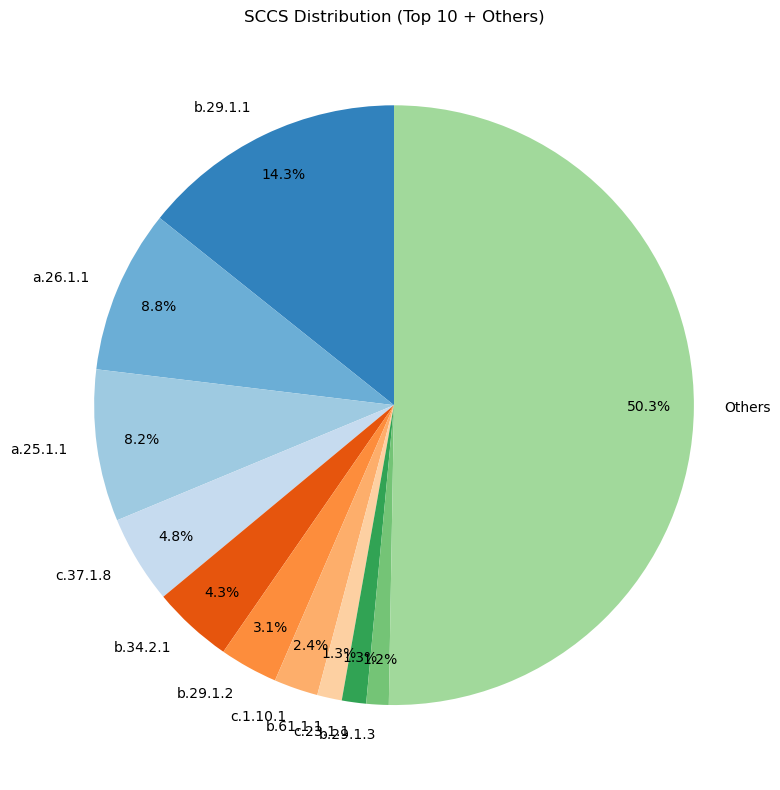

In [198]:
import matplotlib.pyplot as plt
import pandas as pd



top_n = 10
top_sccs = sccs_counts.head(top_n)
others = sccs_counts[top_n:].sum()

plot_data = pd.concat([top_sccs, pd.Series({'Others': others})])

plt.figure(figsize=(12, 8))
colors = plt.cm.tab20c(range(len(plot_data)))

plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', 
        startangle=90, colors=colors,
        pctdistance=0.85,
        labeldistance=1.1)

plt.title(f'SCCS Distribution (Top {top_n} + Others)')
plt.tight_layout()
plt.savefig(
    "sccs_pie_cpdb.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()

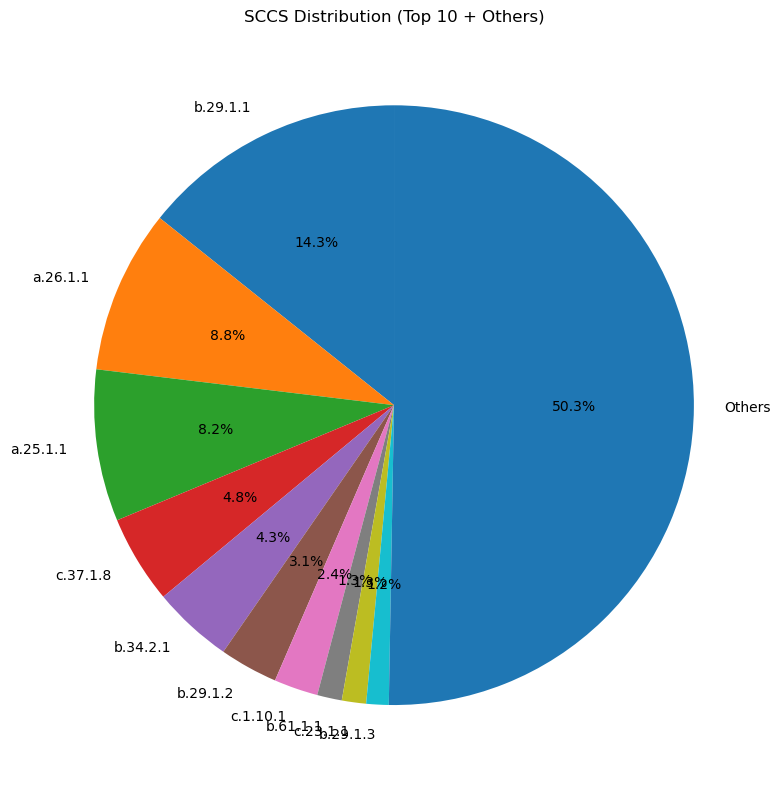

In [189]:
# Top 10 + "Others"
top_n = 10
top_sccs = sccs_counts.head(top_n)
others = sccs_counts[top_n:].sum()

plot_data = pd.concat([top_sccs, pd.Series({'Others': others})])

# Use a better color palette
plt.figure(figsize=(10, 8))
colors = plt.cm.tab20c(range(len(plot_data)))  # Or try: tab20, Set3, Paired
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=90)
plt.title(f'SCCS Distribution (Top {top_n} + Others)')
plt.tight_layout()
plt.show()

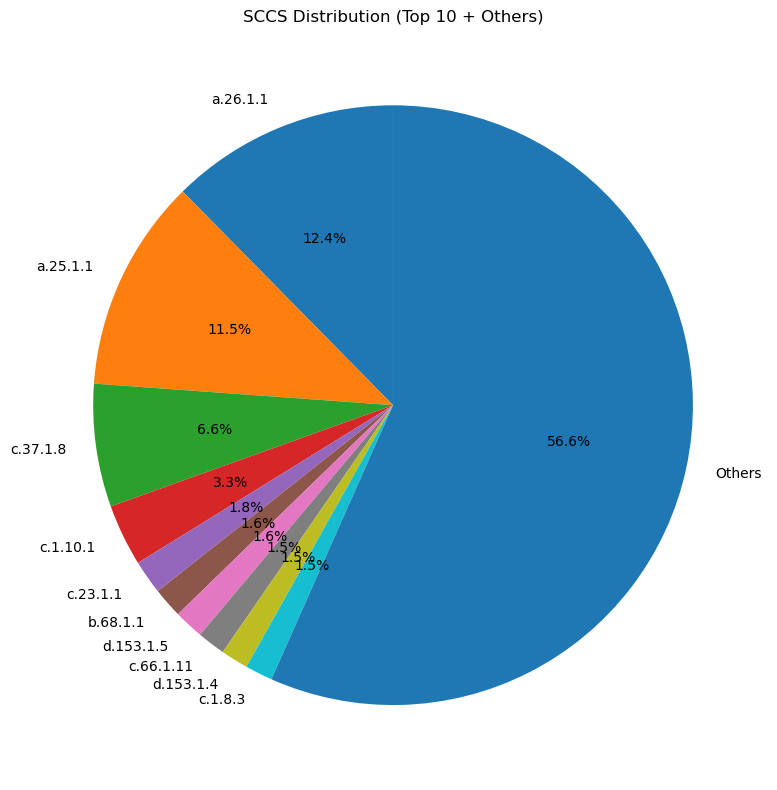

In [172]:
# Top 10 + "Others"
import matplotlib.pyplot as plt

top_n = 10
top_sccs = sccs_counts.head(top_n)
others = sccs_counts[top_n:].sum()

plot_data = pd.concat([top_sccs, pd.Series({'Others': others})])

plt.figure(figsize=(10, 8))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=90)
plt.title(f'SCCS Distribution (Top {top_n} + Others)')
plt.tight_layout()
plt.show()

In [162]:
nocona_no_sameuniprot[
    (nocona_no_sameuniprot['Protein1_sccs'].str.startswith('b.34', na=False)) |
    (nocona_no_sameuniprot['Protein2_sccs'].str.startswith('b.34', na=False))
]

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
2246,1g5vA,1hzaA,0.48679,0.62670,0.42676,0.54993,0.538699,0.632199,b.34.9.1,b.40.4.5,0.12317,Q16637,P41016
2247,1g5vA,1i5fA,0.48532,0.62722,0.43024,0.55688,0.547933,0.645458,b.34.9.1,b.40.4.5,0.12664,Q16637,P41016
2248,1g5vA,1c9oA,0.48373,0.62796,0.42903,0.55753,0.550905,0.649586,b.34.9.1,b.40.4.5,0.12850,Q16637,P41016
2249,1g5vA,1hzcA,0.48728,0.62816,0.43184,0.55742,0.550845,0.642297,b.34.9.1,b.40.4.5,0.12558,Q16637,P41016
2250,1g5vA,1mjcA,0.52200,0.66633,0.44515,0.56926,0.508240,0.620901,b.34.9.1,b.40.4.5,0.12411,Q16637,P0A9X9
2251,1g5vA,1hz9A,0.48351,0.62861,0.42877,0.55784,0.547993,0.643698,b.34.9.1,b.40.4.5,0.12907,Q16637,P41016
2252,1g5vA,1hzbA,0.48697,0.63171,0.43113,0.56082,0.547896,0.630664,b.34.9.1,b.40.4.5,0.12969,Q16637,P41016
2253,1g5vA,1cspA,0.48515,0.62415,0.42495,0.54770,0.544774,0.637684,b.34.9.1,b.40.4.5,0.12275,Q16637,P32081
2256,1gcqA,1k2bA,0.31712,0.31712,0.24223,0.24223,0.737013,0.606516,b.34.2.1,b.50.1.1,0.00000,P62993,P04587
2282,1mhnA,1hzaA,0.47498,0.62648,0.43150,0.56999,0.569274,0.660935,b.34.9.1,b.40.4.5,0.13849,Q16637,P41016


In [134]:
df_sccs_fixed[df_sccs_fixed['Protein1_uniprot'] == 'P02701']

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
2083,1avdA,1swfA,0.55821,0.79373,0.55690,0.55690,0.865914,0.785312,b.61.1.1,b.61.1.1,0.00000,P02701,P22629
2106,1ravA,1swfA,0.55573,0.78967,0.55413,0.55413,0.857749,0.781628,b.61.1.1,b.61.1.1,0.00000,P02701,P22629
2126,1vyoA,1swfA,0.56631,0.80513,0.56618,0.56618,0.856174,0.804376,b.61.1.1,b.61.1.1,0.00000,P02701,P22629
2130,2a5bA,1swfA,0.55674,0.78941,0.55580,0.55580,0.864831,0.786329,b.61.1.1,b.61.1.1,0.00000,P02701,P22629
2131,2a5bA,2g16B,0.39612,0.39612,0.32451,0.32451,0.637308,0.559342,b.61.1.1,NaN,0.00000,P02701,P42212
2132,2a5cA,1swfA,0.56115,0.79762,0.56148,0.56148,0.866471,0.792214,b.61.1.1,b.61.1.1,0.00000,P02701,P22629
2133,2a8gA,1swfA,0.56840,0.80849,0.56921,0.56921,0.873665,0.797541,b.61.1.1,b.61.1.1,0.00000,P02701,P22629
2134,2c4iA,1stpA,0.28615,0.43872,0.28615,0.43872,0.835886,0.836696,NaN,b.61.1.1,0.15257,P02701,P22629
2135,2c4iA,1ravA,0.31284,0.48434,0.31284,0.48434,0.854786,0.849122,NaN,b.61.1.1,0.17150,P02701,P02701
2136,2c4iA,2a5cA,0.31768,0.45814,0.31768,0.45814,0.858629,0.831066,NaN,b.61.1.1,0.14046,P02701,P02701


In [130]:
df_sccs_fixed[df_sccs_fixed['Protein2'] == '4gd9A']

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot


In [115]:
len(df_sccs_fixed)

4169

In [118]:
filtered_df

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
855,1a3kA,1mvqA,0.51577,0.72725,0.32732,0.46213,0.974979,0.932912,b.29.1.3,b.29.1.1,0.13481,P17931,P83721
856,1a3kA,1azdA,0.51434,0.72862,0.32676,0.46153,0.975922,0.934158,b.29.1.3,b.29.1.1,0.13477,P17931,P55915
857,1a3kA,1apnA,0.51860,0.72391,0.34162,0.48044,0.927549,0.932822,b.29.1.3,b.29.1.1,0.13882,P17931,P02866
858,1a3kA,1h9pA,0.51468,0.73168,0.33170,0.46724,0.972956,0.934259,b.29.1.3,b.29.1.1,0.13554,P17931,P81637
859,1a3kA,1h9wA,0.51317,0.72629,0.33226,0.46980,0.969301,0.935533,b.29.1.3,b.29.1.1,0.13754,P17931,P81637
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1765,2gdfA,2a6xA,0.39747,0.72928,0.39747,0.72928,0.915168,0.987943,b.29.1.1,b.29.1.13,0.33181,P08902,Q12396
1766,2gdfA,1viwB,0.43622,0.77350,0.43622,0.77350,0.955188,0.976037,b.29.1.1,b.29.1.1,0.33728,P08902,P02873
1767,2gdfA,2a6yA,0.40349,0.74206,0.39563,0.72774,0.916361,0.988260,b.29.1.1,b.29.1.13,0.33211,P08902,P43555
1768,2gdfA,2a6zA,0.39955,0.73186,0.39955,0.73186,0.912644,0.988779,b.29.1.1,b.29.1.13,0.33231,P08902,P43555


In [126]:
mask = (df_sccs_fixed['Protein1_sccs'].str.startswith('b.29.1') & 
            df_sccs_fixed['Protein2_sccs'].str.startswith('b.29.1'))
    
    
filtered_df = df_sccs_fixed[mask]

filtered_df

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
855,1a3kA,1mvqA,0.51577,0.72725,0.32732,0.46213,0.974979,0.932912,b.29.1.3,b.29.1.1,0.13481,P17931,P83721
856,1a3kA,1azdA,0.51434,0.72862,0.32676,0.46153,0.975922,0.934158,b.29.1.3,b.29.1.1,0.13477,P17931,P55915
857,1a3kA,1apnA,0.51860,0.72391,0.34162,0.48044,0.927549,0.932822,b.29.1.3,b.29.1.1,0.13882,P17931,P02866
858,1a3kA,1h9pA,0.51468,0.73168,0.33170,0.46724,0.972956,0.934259,b.29.1.3,b.29.1.1,0.13554,P17931,P81637
859,1a3kA,1h9wA,0.51317,0.72629,0.33226,0.46980,0.969301,0.935533,b.29.1.3,b.29.1.1,0.13754,P17931,P81637
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1765,2gdfA,2a6xA,0.39747,0.72928,0.39747,0.72928,0.915168,0.987943,b.29.1.1,b.29.1.13,0.33181,P08902,Q12396
1766,2gdfA,1viwB,0.43622,0.77350,0.43622,0.77350,0.955188,0.976037,b.29.1.1,b.29.1.1,0.33728,P08902,P02873
1767,2gdfA,2a6yA,0.40349,0.74206,0.39563,0.72774,0.916361,0.988260,b.29.1.1,b.29.1.13,0.33211,P08902,P43555
1768,2gdfA,2a6zA,0.39955,0.73186,0.39955,0.73186,0.912644,0.988779,b.29.1.1,b.29.1.13,0.33231,P08902,P43555


In [128]:
filtered_df[['progres_score', 'cirpin_score']].describe()


,progres_score,cirpin_score
count,815.000000,815.000000
mean,0.923463,0.950303
std,0.139282,0.089775
min,0.497693,0.682839
25%,0.951153,0.958381
50%,0.976847,0.990451
75%,0.989948,0.996070
max,0.995621,0.999112


In [109]:
mask = (df_sccs_fixed['Protein1'].str.startswith('1un2A') )
    
    
filtered_df2 = df[mask]
    
filtered_df2

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
4155,1un2A,1bq7A,0.51353,0.96431,0.51353,0.96431,0.989165,0.995577,c.47.1.13,c.47.1.13,0.45078,P0AEG4,P0AEG4
4156,1un2A,2b3sA,0.47834,0.91446,0.47593,0.90986,0.985751,0.993427,c.47.1.13,c.47.1.13,0.43393,P0AEG4,P0AEG4


In [90]:
b29_sccs = [(sccs, count) for sccs, count in sorted_sccs 
            if isinstance(sccs, str) and sccs.startswith('b.29.1')]

b29_sccs

total = [count for sccs, count in b29_sccs]
sum(total)

1670

In [91]:
len(all_sccs)

8338

In [88]:
b29_sccs

[('b.29.1.1', 1136),
 ('b.29.1.2', 250),
 ('b.29.1.3', 96),
 ('b.29.1.13', 76),
 ('b.29.1.11', 27),
 ('b.29.1.0', 25),
 ('b.29.1.18', 17),
 ('b.29.1.4', 14),
 ('b.29.1.17', 13),
 ('b.29.1.20', 5),
 ('b.29.1.24', 4),
 ('b.29.1.22', 4),
 ('b.29.1.5', 3)]

In [112]:
# Combine both SCCS columns into a single list
all_sccs = df_sccs_fixed['Protein1_sccs'].tolist() + df_sccs_fixed['Protein2_sccs'].tolist()

# Count occurrences manually
sccs_counts = {}
for sccs in all_sccs:
    if sccs in sccs_counts:
        sccs_counts[sccs] += 1
    else:
        sccs_counts[sccs] = 1

# Sort by count (descending)
sorted_sccs = sorted(sccs_counts.items(), key=lambda x: x[1], reverse=True)

# Display the most common SCCS values
print("Most common SCCS values:")
for sccs, count in sorted_sccs:
    if isinstance(sccs, str) and sccs.startswith('c.47'):
        print('adfgasdfasdfasfdsafasfdasf')
    print(f"{sccs}: {count}")

Most common SCCS values:
b.29.1.1: 1136
a.26.1.1: 702
a.25.1.1: 651
c.37.1.8: 379
nan: 378
b.34.2.1: 345
b.29.1.2: 250
c.1.10.1: 189
b.61.1.1: 106
c.23.1.1: 104
b.29.1.3: 96
b.68.1.1: 92
d.153.1.5: 91
c.66.1.11: 86
c.1.8.3: 84
d.153.1.4: 84
b.29.1.13: 76
c.44.1.1: 71
b.34.2.0: 67
b.69.2.1: 65
c.1.2.3: 62
c.23.5.1: 57
c.1.7.1: 54
b.69.2.2: 51
c.1.23.1: 49
c.1.21.1: 48
b.68.6.1: 46
c.1.2.4: 46
c.1.10.4: 46
e.3.1.1: 45
b.69.4.0: 42
c.1.1.1: 42
b.69.4.2: 41
b.1.1.1: 40
c.45.1.1: 39
b.50.1.1: 37
c.45.1.0: 37
c.1.4.1: 35
a.39.1.5: 34
c.37.1.0: 33
b.36.1.6: 32
c.1.12.5: 32
b.36.1.1: 31
c.1.10.2: 31
g.3.3.1: 29
a.25.1.0: 28
b.11.1.1: 28
c.1.2.1: 28
b.29.1.11: 27
c.2.1.2: 27
c.37.1.19: 27
c.1.16.3: 26
c.86.1.1: 26
b.29.1.0: 25
b.69.4.1: 24
adfgasdfasdfasfdsafasfdasf
c.47.1.13: 23
c.1.9.1: 23
a.39.1.1: 22
c.46.1.3: 22
c.26.2.4: 21
d.58.1.2: 20
d.58.1.4: 20
d.58.14.1: 20
c.37.1.18: 19
a.118.1.4: 18
b.34.9.1: 18
c.1.6.2: 18
c.61.1.1: 18
b.40.4.5: 18
b.29.1.18: 17
c.1.15.7: 17
c.116.1.3: 16
d.58.30

In [66]:
df[
    (df['Protein1_sccs'].str.startswith('c.47')) |
    (df['Protein2_sccs'].str.startswith('c.47.'))
]

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
3254,1aiuA,1yd3A,0.29625,0.29625,0.29625,0.29625,0.737986,0.779702,c.47.1.1,NaN,0.00000,P10599,Q9WYA3
3270,1aucA,1yd4A,0.29601,0.29601,0.29601,0.29601,0.750949,0.794300,c.47.1.1,NaN,0.00000,P10599,Q9WYA3
3271,1aucA,1yd3A,0.30501,0.30501,0.30501,0.30501,0.736174,0.780100,c.47.1.1,NaN,0.00000,P10599,Q9WYA3
3272,1aucA,1yczA,0.30216,0.30216,0.30216,0.30216,0.756144,0.792915,c.47.1.1,NaN,0.00000,P10599,Q9WYA3
3296,1cqgA,1yd4A,0.30834,0.30834,0.30834,0.30834,0.744636,0.789095,c.47.1.1,NaN,0.00000,P10599,Q9WYA3
3297,1cqgA,1yczA,0.29787,0.29787,0.29787,0.29787,0.749936,0.787809,c.47.1.1,NaN,0.00000,P10599,Q9WYA3
4098,1wwjA,1cgqA,0.42535,0.42535,0.38747,0.38747,0.702264,0.710574,c.47.1.15,d.80.1.3,0.00000,P74645,P14174
4099,1wwjA,1mffA,0.42060,0.42060,0.38456,0.38456,0.721485,0.710125,c.47.1.15,d.80.1.3,0.00000,P74645,P34884
4148,1a23A,1un2A,0.45417,0.81368,0.45417,0.81368,0.984426,0.988718,c.47.1.13,c.47.1.13,0.35951,P0AEG4,P0AEG4
4149,1ac1A,1un2A,0.50342,0.93870,0.50342,0.93870,0.984774,0.991518,c.47.1.13,c.47.1.13,0.43528,P0AEG4,P0AEG4


In [45]:
df[
    (df['Protein1_sccs'] == 'b.29.*') &
    (df['Protein2_sccs'] == 'b.29.*')
]


,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
5,1fp3A,1ks8A,0.63233,0.69125,0.59385,0.64707,0.958750,0.982420,a.102.1.3,l.1.1.1,0.05322,P17560,O77044
7,1nc5A,1ghqA,0.58885,0.64552,0.58885,0.64552,0.920800,0.963621,a.102.1.6,l.1.1.1,0.05667,O34559,P01024
8,1nc5A,1c3dA,0.57529,0.62801,0.57529,0.62801,0.913858,0.969388,a.102.1.6,l.1.1.1,0.05272,O34559,P01024
11,1vd5A,2afaA,0.73364,0.73364,0.69877,0.69877,0.971409,0.993711,a.102.1.7,l.1.1.1,0.00000,Q9RC92,Q8ZKT7
12,1vd5A,1ghqA,0.57596,0.61819,0.57596,0.61819,0.915184,0.939185,a.102.1.7,l.1.1.1,0.04223,Q9RC92,P01024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4142,2ia9A,1z54A,0.28595,0.43832,0.23176,0.33676,0.373151,0.555988,l.1.1.1,d.38.1.1,0.10500,P28015,Q5SJV0
4143,2ia9A,2cyeA,0.29195,0.46240,0.23613,0.35714,0.379729,0.568722,l.1.1.1,d.38.1.1,0.12101,P28015,Q5SH84
4144,2ifxA,2ns1B,0.45049,0.45049,0.41738,0.41738,0.681094,0.780646,l.1.1.1,l.1.1.1,0.00000,O51799,P0AC55
4146,2ivyA,2ak7A,0.34006,0.34006,0.34006,0.34006,0.705032,0.702675,d.58.58.1,l.1.1.1,0.00000,Q97YC2,O06976


In [ ]:
df[df['tm_score_min_difference'].between(0.4, 0.5)]
